In [5]:
import numpy as np
import matplotlib as plt
import pandas as pd
import seaborn as sns
import sklearn as skl

In [6]:
df=pd.read_csv('global_ev_adoption_behavior_2026.csv');
print(df.head());
print(df.isnull().sum());
print(df.isnull().sum().sum());

df['education_level']=df['education_level'].fillna(df['education_level'].mode()[0]);
df['charging_station_accessibility']=df['charging_station_accessibility'].fillna(df['charging_station_accessibility'].mean());
df['ev_knowledge_score']=df['ev_knowledge_score'].fillna(df['ev_knowledge_score'].median());


   age  annual_income  ... monthly_energy_consumption_kwh monthly_charging_cost
0   56        23019.0  ...                          199.8                  28.5
1   46        26440.0  ...                          139.8                  22.9
2   46        57167.0  ...                          158.0                  38.5
3   23        15841.0  ...                          207.0                  45.0
4   50        51571.0  ...                          195.6                  43.9

[5 rows x 23 columns]
age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
env

In [7]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());
print(df.duplicated().sum());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64
0
                                     age  ...  monthly_charging_cost
age                             1.000000  ...              -0.002225
annual_income      

In [8]:
print(df.isna().sum());
print(df.isna().sum().sum());
print(df.select_dtypes(include=np.number).corr());
print(df.describe());

age                               0
annual_income                     0
education_level                   0
city_type                         0
daily_commute_km                  0
weekly_travel_distance_km         0
current_vehicle_type              0
vehicle_age_years                 0
fuel_expense_per_month            0
charging_station_accessibility    0
nearest_charging_station_km       0
home_charging_available           0
electricity_cost_per_kwh          0
environmental_awareness_score     0
government_incentive_awareness    0
technology_affinity_score         0
range_anxiety_score               0
battery_replacement_concern       0
ev_knowledge_score                0
previous_ev_experience            0
ev_adoption_likelihood            0
monthly_energy_consumption_kwh    0
monthly_charging_cost             0
dtype: int64
0
                                     age  ...  monthly_charging_cost
age                             1.000000  ...              -0.002225
annual_income      

                       age  annual_income  daily_commute_km
age               1.000000      -0.004244         -0.005042
annual_income    -0.004244       1.000000          0.000434
daily_commute_km -0.005042       0.000434          1.000000


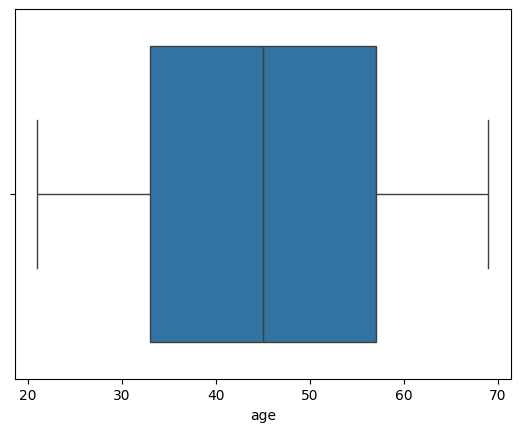

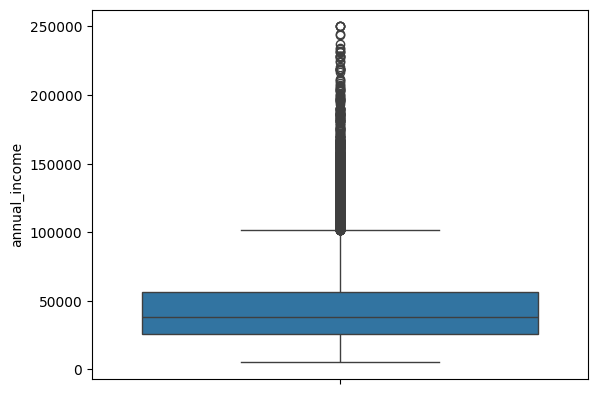

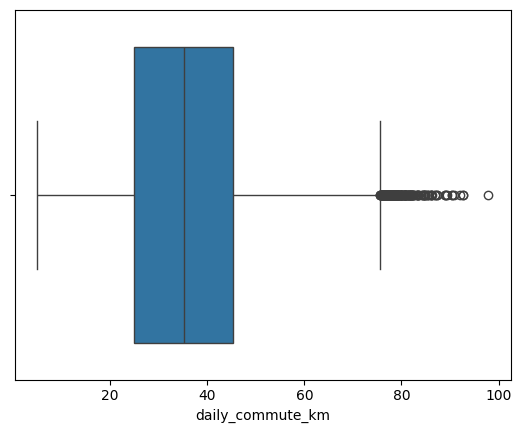

In [9]:
print(df[['age', 'annual_income', 'daily_commute_km']].corr())

sns.boxplot(df['age'], orient='h');
plt.pyplot.show();
sns.boxplot(df['annual_income'], orient='v');
plt.pyplot.show();
sns.boxplot(df['daily_commute_km'], orient='h');
plt.pyplot.show();

In [10]:
q1=df['age'].quantile(0.25);
q3=df['age'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for age is:',q1,',the quantile for age (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['age']>=lower_bound)&(df['age']<=upper_bound)];

the quantile(0.25) for age is: 33.0 ,the quantile for age (0.75) is: 57.0 ,the iqr is: 24.0 ,lower_bound: -3.0 ,upper bound: 93.0


In [11]:
q1=df['daily_commute_km'].quantile(0.25);
q3=df['daily_commute_km'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for daily commute is:',q1,',the quantile for daily commute (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['daily_commute_km']>=lower_bound)&(df['daily_commute_km']<=upper_bound)];

the quantile(0.25) for daily commute is: 25.0 ,the quantile for daily commute (0.75) is: 45.2 ,the iqr is: 20.200000000000003 ,lower_bound: -5.300000000000004 ,upper bound: 75.5


In [12]:
q1=df['annual_income'].quantile(0.25);
q3=df['annual_income'].quantile(0.75);
iqr=q3-q1;
lower_bound=q1-1.5*iqr;
upper_bound=q3+1.5*iqr;
print('the quantile(0.25) for annual_income is:',q1,',the quantile for annual_income (0.75) is:',q3,',the iqr is:',iqr,',lower_bound:',lower_bound,',upper bound:',upper_bound);
df=df[(df['annual_income']>=lower_bound)&(df['annual_income']<=upper_bound)];

the quantile(0.25) for annual_income is: 25620.75 ,the quantile for annual_income (0.75) is: 56052.5 ,the iqr is: 30431.75 ,lower_bound: -20026.875 ,upper bound: 101700.125


outliers for age,daily_commute and annual_income has been removed and the dataset has been updated accordingly.

In [13]:
print(df.head(1))

   age  annual_income  ... monthly_energy_consumption_kwh monthly_charging_cost
0   56        23019.0  ...                          199.8                  28.5

[1 rows x 23 columns]


In [14]:
likelihood_mapping = {'Low': 0, 'Medium': 1, 'High': 2};
df['ev_adoption_likelihood_numeric'] = df['ev_adoption_likelihood'].map(likelihood_mapping);
print(df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr());

                                     age  ...  ev_adoption_likelihood_numeric
age                             1.000000  ...                        0.001857
annual_income                   0.000301  ...                        0.376332
fuel_expense_per_month         -0.004472  ...                        0.003209
daily_commute_km               -0.005122  ...                        0.004344
ev_adoption_likelihood_numeric  0.001857  ...                        1.000000

[5 rows x 5 columns]


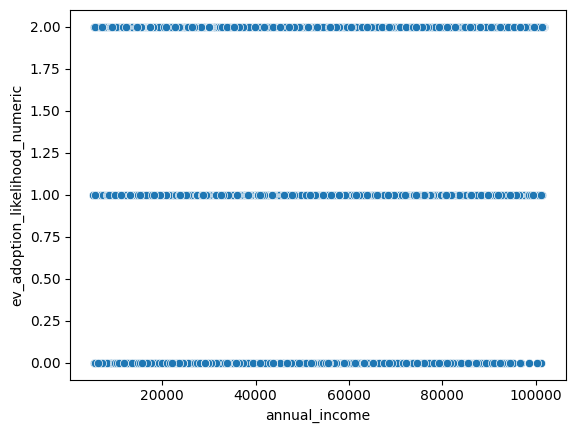

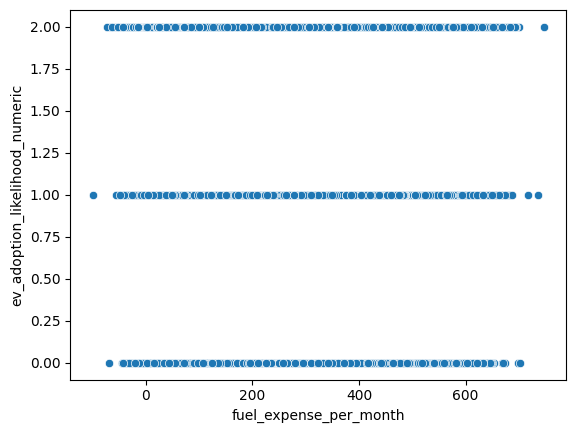

In [15]:
sns.scatterplot(data=df,x='annual_income',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();
sns.scatterplot(data=df,x='fuel_expense_per_month',y='ev_adoption_likelihood_numeric');
plt.pyplot.show();

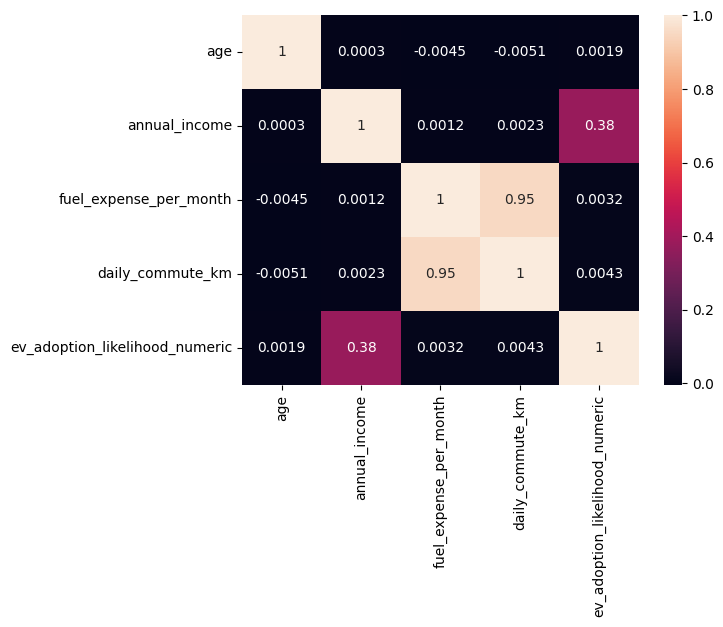

In [16]:
corr = df[['age','annual_income','fuel_expense_per_month','daily_commute_km','ev_adoption_likelihood_numeric']].corr();
sns.heatmap(corr,annot=True);
plt.pyplot.show();

In [17]:
from scipy.stats import pearsonr
pearsonr(
    df['annual_income'],
    df['ev_adoption_likelihood_numeric']
)

PearsonRResult(statistic=np.float64(0.37633238705488953), pvalue=np.float64(0.0))

my summary would be that the likelihood that one will most likely switch to an ev is based on ones own anuual income as it can be seen from the above given heatmap as well and it can also be seen from the pearson coefficient value as well.


In [18]:
from sklearn.feature_selection import VarianceThreshold

df_numeric = df.select_dtypes(include=np.number);
selector = VarianceThreshold(threshold=0.0);
selected_features = selector.fit_transform(df_numeric);
print(f"Original number of numerical features: {df_numeric.shape[1]}");
print(f"Number of features after VarianceThreshold: {selected_features.shape[1]}");
sel1=VarianceThreshold(0.01);
sel1.fit_transform(df_numeric);
print(f"Number of features after VarianceThreshold(0.01): {sel1.transform(df_numeric).shape[1]}");


Original number of numerical features: 20
Number of features after VarianceThreshold: 20
Number of features after VarianceThreshold(0.01): 19


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
X=df[['age','daily_commute_km','annual_income']];
y=df['ev_adoption_likelihood_numeric'];
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42);
model = LinearRegression();
model.fit(X_train,y_train);
y_pred=model.predict(X_test);
mse=mean_squared_error(y_test,y_pred);
r2=r2_score(y_test,y_pred);
print('mean squared error:',mse);
print('r2 score:',r2);

mean squared error: 0.5055328600001558
r2 score: 0.1427860685421185


To potentially improve the R2 score, let's analyze the correlation of all numerical features with ev_adoption_likelihood_numeric to select more predictive features.

In [27]:
import numpy as np
correlation_with_target = df.select_dtypes(include=np.number).corrwith(df['ev_adoption_likelihood_numeric']).sort_values(ascending=False)

print("Correlation of numerical features with 'ev_adoption_likelihood_numeric':\n")
print(correlation_with_target)
top_features = correlation_with_target[1:6].index.tolist()

print(f"\nTop 5 features with highest correlation to 'ev_adoption_likelihood_numeric': {top_features}")

Correlation of numerical features with 'ev_adoption_likelihood_numeric':

ev_adoption_likelihood_numeric    1.000000
ev_knowledge_score                0.722846
environmental_awareness_score     0.689844
technology_affinity_score         0.680000
annual_income                     0.376332
charging_station_accessibility    0.180364
government_incentive_awareness    0.123834
home_charging_available           0.095642
previous_ev_experience            0.084576
daily_commute_km                  0.004344
weekly_travel_distance_km         0.003984
monthly_charging_cost             0.003217
fuel_expense_per_month            0.003209
monthly_energy_consumption_kwh    0.003045
age                               0.001857
electricity_cost_per_kwh         -0.001343
vehicle_age_years                -0.005918
nearest_charging_station_km      -0.109245
battery_replacement_concern      -0.151925
range_anxiety_score              -0.698002
dtype: float64

Top 5 features with highest correlation to 'ev_ado

Based on the correlations, annual_income, technology_affinity_score, government_incentive_awareness, ev_knowledge_score, and environmental_awareness_score seem to be strong predictors. Let's include these in our model and retrain it.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_new = df[top_features]
y_new = df['ev_adoption_likelihood_numeric']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_test_new)

mse_new = mean_squared_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f'Mean Squared Error with new features: {mse_new}')
print(f'R2 Score with new features: {r2_new}')

Mean Squared Error with new features: 0.20602873011407244
R2 Score with new features: 0.650644474952025


now from this newer r2 score and mse value we can understand that the previous regression model had too little features and the score implies that this is much better and will give much better results as compared to the previous model.